#Info 2950 Project- Phase II 
Members: 
Marianna Ruggiero
mir46@cornell.edu

Joyce Han
jh2969@cornell.edu

Fiona Chandler
fcc42@cornell.edu

Friana Engineer
fe63@cornell.edu

##Research Question 
Question: Is the percentage of US jobs that require AI skills associated with the percentage of Cornell courses that teach about AI over time? Can we predict future Cornell AI class numbers with the percentage of US jobs that require AI skills?

##Data Description 

###Cornell API: https://classes.cornell.edu/content/SU17/api-details 
The Cornell Roster API is an API that enables us to access Class Roster Data from the years xxxx to Spring 2026. 
We obtained the following attributes from the raw data: 
* term: the semester in which the course was offered, such as FA21 or SP25. 
* crseId: the Cornell course identifier. 
* subject: the academic subject or department associated with the course. 
* catalogNbr: the course catalog number. 
* title: the course's title. 
* description: the course description provided by Cornell. 
* college: the Cornell academic group associated with the course. 
* career: the academic career associated with the course.

We also created the following attributes: 
* AI_narrow: indicates whether the course title or description contains "artificial intelligence," "machine learning," or the standalone term "AI." 
* AI_broad: indicates whether the course title or description contains one of the terms in our broader AI definition. 

For our primary analysis we use AI_broad because it captures a wider classification of what it means to have a course that focuses on teaching students AI skills. This data was then grouped by semester and aggragated to understand the total number of courses per semester, per subject. As well as the number of courses from all courses per semester, that teach about AI. In addition to that we obtained the percentage of courses that teach AI. 

The dataset was not orignally created by Cornell, instead we used the Cornell class roster API to create this dataset to answer our research question. 

Some limitations to the dataset is that if there is any missing data from the Cornell Class Roster we would be unable to obtain this missing data. Additionally, the fact that we only have the Cornell roster limits our analysis to only Cornell classes and how those are influenced by the number of AI jobs on the market. Another limitation is that we are determining what it means for a class to be AI focused from the course description. The course description is a very limited version of what the course contents actually are and therefore this is vulnerable to errors since we can only tell so much from the course description. This means that we might be underestimating or overestimating the number of courses that teach AI skills. Lastly, another limitation is the relatively short period of time for which we have course descriptions. If we had a dataset that encompassed more semesters this would allow us to do a more in depth analysis. 

The raw JSON responses downloaded through the API should also be included in our project repository so that the dataset can be reproduced. Our processed dataset can be generated from these raw files using the Python code described above. The JSON files can also be obtained directly from using the Cornell Roster API. 


##Our World in Data- Share of job postings 
hello

In [ ]:
import json, re, time, pathlib
import requests
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
import duckdb
import requests
from bs4 import BeautifulSoup
import time

BASE = "https://classes.cornell.edu/api/2.0"
TERMS = ["FA21", "SP22", "FA22", "SP23", "FA23", "SP24", "FA24", "SP25", "FA25", "SP26"]
#TERMS = ["FA21"]
RAW = pathlib.Path("raw")
RAW.mkdir(exist_ok=True)

successfull response

In [ ]:
def get_subjects(term):
    r = requests.get(f"{BASE}/config/subjects.json", params={"roster": term})
    r.raise_for_status()
    return r.json()["data"]["subjects"]

def fetch(term, subject):
    path = RAW / f"{term}_{subject}.json"
    if path.exists():
        return
    r = requests.get(f"{BASE}/search/classes.json",
                     params={"roster": term, "subject": subject})
    r.raise_for_status()
    path.write_text(json.dumps(r.json()))
    time.sleep(0.5)

failed = []
for term in TERMS:
    for s in get_subjects(term):
        code = s["value"]  # if this errors, print(s) and use the field that holds the subject code
        try:
            fetch(term, code)
        except Exception as e:
            failed.append((term, code, str(e)))
print("failed requests:", len(failed))

failed requests: 1


In [ ]:
rows = []
for path in sorted(RAW.glob("*.json")):
    term = path.stem.split("_", 1)[0]
    classes = json.loads(path.read_text()).get("data", {}).get("classes", [])
    for c in classes:
        rows.append({
            "term": term,
            "crseId": c.get("crseId"),
            "subject": c.get("subject"),
            "catalogNbr": c.get("catalogNbr"),
            "title": c.get("titleLong") or "",
            "description": c.get("description") or "",
            "college": c.get("acadGroup"),
            "career": c.get("acadCareer"),
        })
df = pd.DataFrame(rows)
df["term"] = pd.Categorical(df["term"], categories=TERMS, ordered=True)
print(df.shape)

(45222, 8)


In [ ]:
text = df["title"] + " " + df["description"]

narrow = re.compile(r"artificial intelligence|machine learning", re.I)
broad = re.compile(r"artificial intelligence|machine learning|deep learning|neural network|"
                   r"large language model|natural language processing|reinforcement learning|"
                   r"computer vision", re.I)
ai_word = re.compile(r"\bAI\b")

df["ai_narrow"] = text.apply(lambda t: bool(narrow.search(t) or ai_word.search(t)))
df["ai_broad"] = text.apply(lambda t: bool(broad.search(t) or ai_word.search(t)))

In [ ]:
by_id = df.drop_duplicates(["term", "crseId"])
by_text = df.drop_duplicates(["term", "title", "description"])

rules = {"no dedupe": df, "crseId (main)": by_id, "title+description": by_text}
print(pd.DataFrame({
    name: {"courses": len(d),
           "AI share (narrow)": round(d["ai_narrow"].mean(), 3),
           "AI share (broad)": round(d["ai_broad"].mean(), 3)}
    for name, d in rules.items()
}).T)

                   courses  AI share (narrow)  AI share (broad)
no dedupe          45222.0              0.020             0.024
crseId (main)      36948.0              0.021             0.025
title+description  33691.0              0.019             0.023


      courses  ai_narrow  ai_broad
term                              
FA21     3520      0.012     0.016
SP22     3705      0.014     0.015
FA22     3640      0.012     0.015
SP23     3794      0.020     0.022
FA23     3723      0.017     0.021
SP24     3735      0.021     0.025
FA24     3692      0.020     0.025
SP25     3808      0.027     0.030
FA25     3623      0.029     0.033
SP26     3708      0.038     0.041


<Axes: title={'center': 'Share of Cornell courses mentioning AI, by term'}, xlabel='term', ylabel='share of courses mentioning AI'>

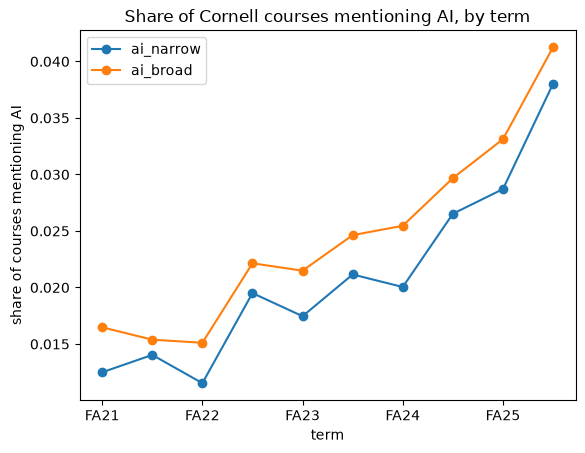

In [ ]:
by_term = by_id.groupby("term", observed=True).agg(
    courses=("crseId", "size"),
    ai_narrow=("ai_narrow", "mean"),
    ai_broad=("ai_broad", "mean"),
)
print(by_term.round(3))
by_term[["ai_narrow", "ai_broad"]].plot(
    marker="o", ylabel="share of courses mentioning AI",
    title="Share of Cornell courses mentioning AI, by term")

In [ ]:
by_subject = (by_id.groupby("subject")
              .agg(courses=("crseId", "size"),
                   ai_courses=("ai_broad", "sum"),
                   share=("ai_broad", "mean"))
              .query("courses >= 20")
              .sort_values("share", ascending=False))
print(by_subject.head(15).round(3))

         courses  ai_courses  share
subject                            
CS           928         276  0.297
BIOCB         55          12  0.218
INFO         510          69  0.135
STSCI        297          34  0.114
SYSEN        222          22  0.099
ORIE         469          45  0.096
ECE          515          48  0.093
NBAY         151          14  0.093
CHEME        324          27  0.083
PLBIO        109           8  0.073
ENMGT         58           4  0.069
TECH          94           6  0.064
MGMT          85           5  0.059
COGST        241          14  0.058
NBA          709          39  0.055


In [ ]:
blank = by_id["description"].str.strip() == ""
print(blank.groupby(by_id["term"], observed=True).mean().round(3))

term
FA21    0.036
SP22    0.048
FA22    0.029
SP23    0.047
FA23    0.024
SP24    0.034
FA24    0.012
SP25    0.029
FA25    0.016
SP26    0.018
Name: description, dtype: float64


In [ ]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/share-artificial-intelligence-job-postings.csv?v=1&csvType=full&useColumnShortNames=false", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df = df[df["Code"]=='USA']
# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/share-artificial-intelligence-job-postings.metadata.json?v=1&csvType=full&useColumnShortNames=false").json()

print(df)
x = df['Year']
y = df['Share of artificial intelligence jobs among all job postings']
plt.plot(x, y, marker='o', linestyle='')
plt.xlabel("Year")
plt.ylabel("Share of artificial intelligence jobs among all job postings")
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, 'r', label='Fitted line')

X = np.array(df['Year']).reshape(12,1)
Y = np.array(df['Share of artificial intelligence jobs among all job postings']).reshape(12,1)
model =LinearRegression().fit(X, Y)
slope = model.coef_[0][0]
intercept = model.intercept_[0]
print(slope)
print(intercept)

y_pred = model.predict(X).flatten()
residuals = y - y_pred
results_df = pd.DataFrame({
    'X': X.flatten(),
    'Actual': y,
    'Predicted': y_pred,
    'Residual': residuals
})

# Display results
print(results_df)
